# Specialty-Level Medicare Payment Analysis and Fraud Context

This notebook extends the exploratory data analysis by examining how Medicare payment distributions vary across medical specialties. Because Medicare payment amounts are highly right-skewed, log-transformed payments are used to enable meaningful comparison across specialties. Rather than identifying fraud directly, this analysis characterizes payment environments in which anomalous or costly billing behavior may occur.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
# Just peek at first 10 lines
with open("/dsa/groups/casestudycf25/team02/unified_dataset.csv") as f:
    for i in range(10):
        print(f.readline().strip())

npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,avg_suplr_sbmtd_chrg_std,avg_suplr_mdcr_alowd_amt_std,avg_suplr_mdcr_pymt_amt_std,avg_suplr_mdcr_stdzd_amt_std,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs

## Preparing Medicare Payment Data for Visualization

Because the dataset exceeds memory limits, data are processed in chunks before transformation and visualization. During this process, the average Medicare payment variable is extracted and transformed using a natural logarithm. The log transformation reduces right-skewness and allows differences across specialties to be interpreted in multiplicative rather than additive terms.
This step ensures that subsequent visualizations reflect meaningful distributional patterns rather than being dominated by extreme outliers.


In [3]:
import pandas as pd

chunksize = 20000  # smaller chunks
csv_file = "/dsa/groups/casestudycf25/team02/unified_dataset.csv"

# Read first chunk only
chunk_iter = pd.read_csv(csv_file, chunksize=chunksize)

first_chunk = next(chunk_iter)  # just the first chunk
first_chunk.head()

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,...,physician_covered_recipient,year_leie,excltype,num_exclusions_alltime,num_exclusion_types_alltime,fraud_flag,Rfrg_NPI,specialty_type,specialty_lvl1,specialty
0,1003000126,2021,0,129.776563,41.940392,31.813932,34.260562,519.106250,167.761567,127.255730,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
1,1003000126,2022,0,209.273634,54.750832,41.764741,52.602407,418.547268,109.501664,83.529481,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
2,1003000126,2023,0,152.346111,48.740210,32.699442,42.116461,457.038333,146.220631,98.098326,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
3,1003000480,2021,0,272.003846,80.513846,64.407692,84.701538,272.003846,80.513846,64.407692,...,0.0,NaN,NaN,NaN,NaN,0,1003000480,Medical Doctor,Allopathic & Osteopathic Physicians,General Surgery
4,1003000522,2021,0,133.101129,22.805968,18.243952,19.471129,266.202258,45.611935,36.487903,...,NaN,NaN,NaN,NaN,NaN,0,1003000522,Doctor of Osteopathy,Allopathic & Osteopathic Physicians,Family Practice


In [4]:
first_chunk.columns.tolist()

['npi',
 'year',
 'target',
 'avg_suplr_sbmtd_chrg_mean',
 'avg_suplr_mdcr_alowd_amt_mean',
 'avg_suplr_mdcr_pymt_amt_mean',
 'avg_suplr_mdcr_stdzd_amt_mean',
 'avg_suplr_sbmtd_chrg_sum',
 'avg_suplr_mdcr_alowd_amt_sum',
 'avg_suplr_mdcr_pymt_amt_sum',
 'avg_suplr_mdcr_stdzd_amt_sum',
 'avg_suplr_sbmtd_chrg_median',
 'avg_suplr_mdcr_alowd_amt_median',
 'avg_suplr_mdcr_pymt_amt_median',
 'avg_suplr_mdcr_stdzd_amt_median',
 'avg_suplr_sbmtd_chrg_std',
 'avg_suplr_mdcr_alowd_amt_std',
 'avg_suplr_mdcr_pymt_amt_std',
 'avg_suplr_mdcr_stdzd_amt_std',
 'avg_suplr_sbmtd_chrg_min',
 'avg_suplr_mdcr_alowd_amt_min',
 'avg_suplr_mdcr_pymt_amt_min',
 'avg_suplr_mdcr_stdzd_amt_min',
 'avg_suplr_sbmtd_chrg_max',
 'avg_suplr_mdcr_alowd_amt_max',
 'avg_suplr_mdcr_pymt_amt_max',
 'avg_suplr_mdcr_stdzd_amt_max',
 'tot_suplr_nonrntl_hcpcs_cds',
 'tot_suplr_rentl_hcpcs_cds',
 'tot_suplrs_mean',
 'tot_suplr_benes_mean',
 'tot_suplr_clms_mean',
 'tot_suplr_srvcs_mean',
 'tot_suplrs_sum',
 'tot_suplr_benes_s

In [5]:
# Convert float64 -> float32 and int64 -> int32
for col in first_chunk.select_dtypes(include=['float64']).columns:
    first_chunk[col] = pd.to_numeric(first_chunk[col], downcast='float')
for col in first_chunk.select_dtypes(include=['int64']).columns:
    first_chunk[col] = pd.to_numeric(first_chunk[col], downcast='integer')

print(first_chunk.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 169 entries, npi to specialty
dtypes: float32(150), int16(5), int32(5), int8(4), object(5)
memory usage: 12.9+ MB
None


In [6]:
for i, chunk in enumerate(pd.read_csv(csv_file, chunksize=chunksize)):
    # Example: count rows in each chunk
    print(f"Chunk {i} has {len(chunk)} rows")
    
    # Example: get mean of a numeric column
    if 'payment_amount' in chunk.columns:
        print(f"Mean payment in chunk {i}: {chunk['payment_amount'].mean()}")

Chunk 0 has 20000 rows
Chunk 1 has 20000 rows


/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3058: DtypeWarning: Columns (161) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


Chunk 2 has 20000 rows
Chunk 3 has 20000 rows
Chunk 4 has 20000 rows
Chunk 5 has 20000 rows
Chunk 6 has 20000 rows
Chunk 7 has 20000 rows
Chunk 8 has 20000 rows
Chunk 9 has 20000 rows
Chunk 10 has 20000 rows
Chunk 11 has 20000 rows
Chunk 12 has 20000 rows
Chunk 13 has 20000 rows
Chunk 14 has 20000 rows
Chunk 15 has 20000 rows
Chunk 16 has 20000 rows
Chunk 17 has 20000 rows
Chunk 18 has 20000 rows
Chunk 19 has 20000 rows
Chunk 20 has 20000 rows
Chunk 21 has 20000 rows
Chunk 22 has 20000 rows
Chunk 23 has 20000 rows
Chunk 24 has 20000 rows
Chunk 25 has 20000 rows
Chunk 26 has 20000 rows
Chunk 27 has 20000 rows
Chunk 28 has 20000 rows
Chunk 29 has 20000 rows
Chunk 30 has 20000 rows
Chunk 31 has 20000 rows
Chunk 32 has 20000 rows
Chunk 33 has 20000 rows
Chunk 34 has 20000 rows
Chunk 35 has 20000 rows
Chunk 36 has 20000 rows
Chunk 37 has 20000 rows
Chunk 38 has 20000 rows
Chunk 39 has 20000 rows
Chunk 40 has 20000 rows
Chunk 41 has 20000 rows
Chunk 42 has 20000 rows
Chunk 43 has 13538 rows


In [7]:
# Basic statistics for numeric columns
numeric_cols = first_chunk.select_dtypes(include=['float32', 'int32', 'int16', 'int8']).columns
first_chunk[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
npi,20000.0,1.010266e+09,6.670911e+06,1.003000e+09,1.003813e+09,1.013096e+09,1.013914e+09,1.023082e+09
year,20000.0,2.021994e+03,8.166386e-01,2.021000e+03,2.021000e+03,2.022000e+03,2.023000e+03,2.023000e+03
target,20000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
avg_suplr_sbmtd_chrg_mean,20000.0,2.655209e+02,5.924061e+02,3.766667e-02,6.667255e+01,1.433617e+02,2.606245e+02,2.100000e+04
avg_suplr_mdcr_alowd_amt_mean,20000.0,1.022159e+02,3.591980e+02,1.016667e-02,1.914041e+01,5.127849e+01,8.538710e+01,1.528944e+04
...,...,...,...,...,...,...,...,...
excltype,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_exclusions_alltime,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_exclusion_types_alltime,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fraud_flag,20000.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [8]:
# Check missing values
missing = first_chunk.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

num_exclusion_types_alltime                                 20000
excltype                                                    20000
year_leie                                                   20000
num_exclusions_alltime                                      20000
form_count_dividend_profit_or_other_return_on_investment    14194
                                                            ...  
tot_suplrs_std                                               4670
avg_suplr_mdcr_stdzd_amt_std                                 4670
avg_suplr_mdcr_pymt_amt_std                                  4670
avg_suplr_mdcr_alowd_amt_std                                 4670
avg_suplr_sbmtd_chrg_std                                     4670
Length: 78, dtype: int64

# Median Medicare Payment Analysis by Specialty

In this section, we analyze Medicare payment data by specialty type. The goal is to visualize the **median payment per specialty** and identify the **top individual specialties** with the highest median payments. Additionally, we collect all rows flagged as fraudulent for further analysis.

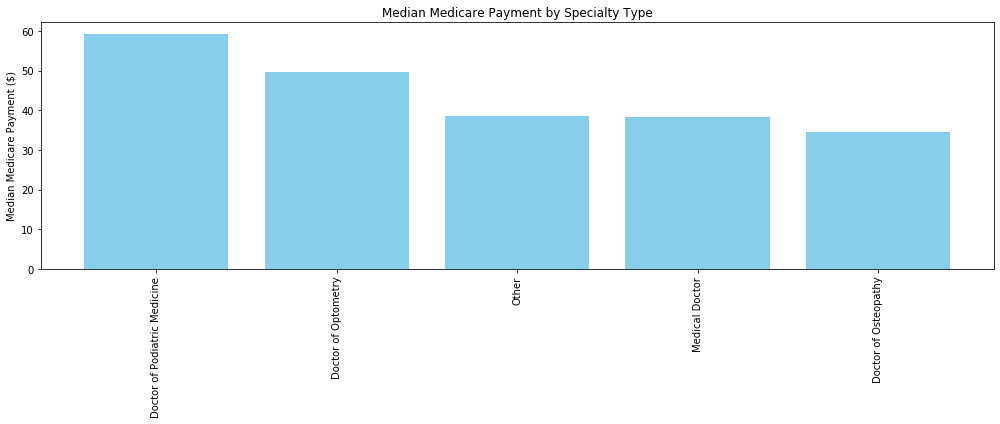

In [9]:
# ----------------------
# Bar plot: median payment per specialty
# ----------------------
df_median = first_chunk.groupby('specialty_type')['avg_suplr_mdcr_pymt_amt_mean'] \
                       .median() \
                       .sort_values(ascending=False) \
                       .reset_index()

plt.figure(figsize=(14,6))
plt.bar(df_median['specialty_type'], df_median['avg_suplr_mdcr_pymt_amt_mean'], color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Median Medicare Payment ($)')
plt.title('Median Medicare Payment by Specialty Type')
plt.tight_layout()
plt.show()

- We group the data by `specialty_type` and calculate the **median Medicare payment** for each specialty.
- Sorting allows us to see the specialties with the highest median payments at the top.
- A bar plot is used to provide a visual comparison across all specialty types.
- Rotation of x-axis labels ensures readability.

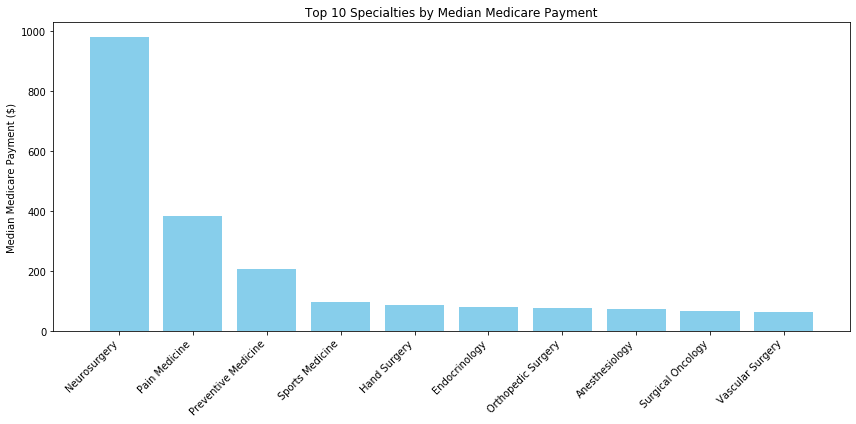

In [10]:
# ----------------------
# Top 10 individual specialties by median payment
# ----------------------
df_median = first_chunk.groupby('specialty')['avg_suplr_mdcr_pymt_amt_mean'] \
                       .median() \
                       .sort_values(ascending=False) \
                       .reset_index()

# Take top 10
df_top10 = df_median.head(10)

plt.figure(figsize=(12,6))
plt.bar(df_top10['specialty'], df_top10['avg_suplr_mdcr_pymt_amt_mean'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Medicare Payment ($)')
plt.title('Top 10 Specialties by Median Medicare Payment')
plt.tight_layout()
plt.show()

This step narrows the analysis from broad specialty categories to individual specialties, allowing identification of those associated with the highest median Medicare payments.

# Fraud Analysis in Medicare Data

This section summarizes patterns observed among claims flagged as fraudulent, focusing on specialty-level concentration, rates, and payment magnitude.


In [11]:
# Collect all rows with fraud_flag = 1 from all chunks
fraud_data = pd.DataFrame()  # empty initially

for chunk in pd.read_csv(csv_file, chunksize=chunksize):
    fraud_rows = chunk[chunk['fraud_flag'] == 1]
    if not fraud_rows.empty:
        fraud_data = pd.concat([fraud_data, fraud_rows])

print(f"Total fraud cases: {len(fraud_data)}")
fraud_data.head()

Total fraud cases: 204


,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,...,physician_covered_recipient,year_leie,excltype,num_exclusions_alltime,num_exclusion_types_alltime,fraud_flag,Rfrg_NPI,specialty_type,specialty_lvl1,specialty
26645,1033111000,2021,1,90.000000,48.066667,38.456667,37.146667,90.000000,48.066667,38.456667,...,0.0,2024.0,1128a1,1.0,1.0,1,1033111000,Medical Doctor,Allopathic & Osteopathic Physicians,Otolaryngology
30095,1033280003,2021,1,198.669396,53.257247,39.681147,35.458752,2980.040934,798.858707,595.217207,...,NaN,2022.0,1128a2,1.0,1.0,1,1033280003,Doctor of Osteopathy,Allopathic & Osteopathic Physicians,Family Practice
31682,1033422357,2021,1,288.631415,51.110243,38.854594,45.412010,1154.525662,204.440971,155.418375,...,NaN,2024.0,1128a1,1.0,1.0,1,1033422357,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
31683,1033422357,2022,1,182.316250,75.472167,58.688500,53.212000,364.632500,150.944333,117.377000,...,NaN,2024.0,1128a1,1.0,1.0,1,1033422357,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
31684,1033422357,2023,1,185.862896,85.261946,63.190158,66.823552,371.725792,170.523891,126.380317,...,NaN,2024.0,1128a1,1.0,1.0,1,1033422357,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine


- We iterate through the entire dataset in chunks to **collect all rows flagged as fraud**.
- This approach avoids memory overload when working with large datasets.
- Finally, we print the total number of fraud cases and display the first few rows for inspection.


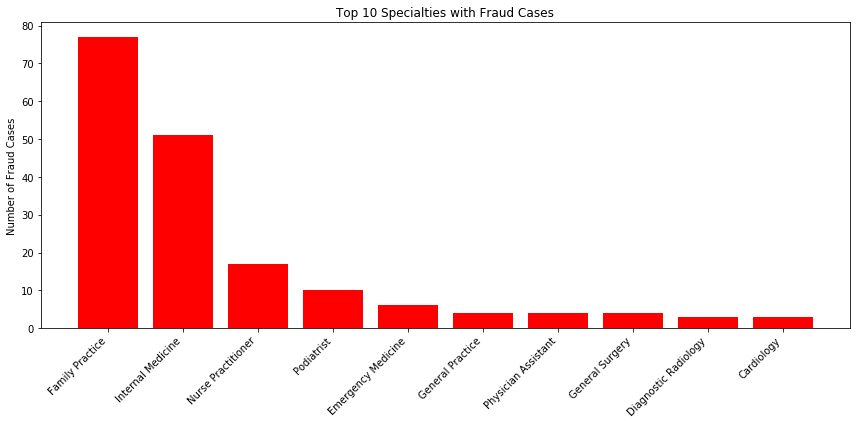

In [12]:
# Top 10 specialties by number of fraud cases
top_fraud_counts = fraud_data['specialty'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_fraud_counts.index, top_fraud_counts.values, color='red')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Fraud Cases')
plt.title('Top 10 Specialties with Fraud Cases')
plt.tight_layout()
plt.show()

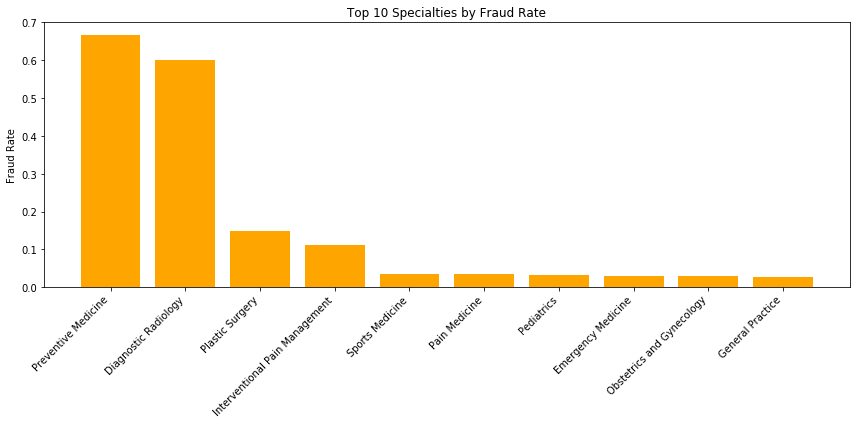

In [13]:
# ----------------------
# Top 10 specialties by fraud rate
# Fraud rate = (# fraud cases) / (total cases per specialty)
# ----------------------
total_cases_per_specialty = first_chunk.groupby('specialty')['fraud_flag'].count()
fraud_cases_per_specialty = fraud_data['specialty'].value_counts()
fraud_rate = (fraud_cases_per_specialty / total_cases_per_specialty).sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(fraud_rate.index, fraud_rate.values, color='orange')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraud Rate')
plt.title('Top 10 Specialties by Fraud Rate')
plt.tight_layout()
plt.show()

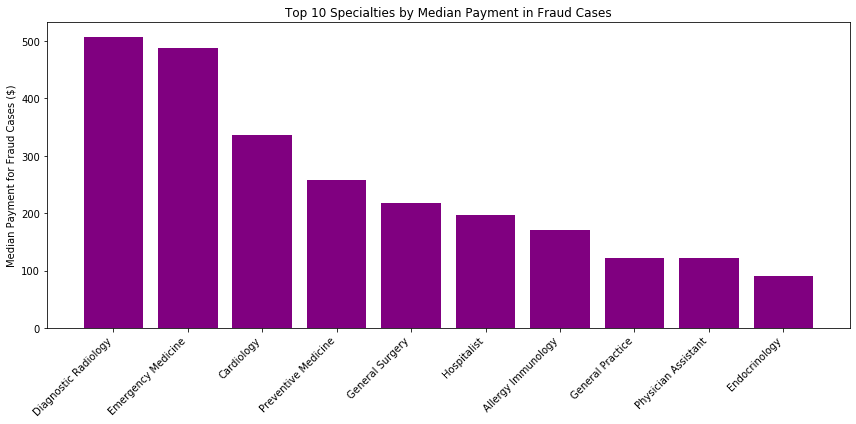

In [14]:
# ----------------------
# Median payment for fraud cases per specialty (top 10)
# ----------------------
payment_fraud = fraud_data.groupby('specialty')['avg_suplr_mdcr_pymt_amt_mean'] \
                          .median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(payment_fraud.index, payment_fraud.values, color='purple')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Payment for Fraud Cases ($)')
plt.title('Top 10 Specialties by Median Payment in Fraud Cases')
plt.tight_layout()
plt.show()

From the fraud analysis:

1. **Total fraud cases:** 204 cases were identified across the dataset.
2. **Top specialties by fraud cases:** Certain specialties have a high number of incidents.
3. **Top specialties by fraud rate:** Some specialties, despite fewer cases, show a high proportion of fraud.
4. **Top specialties by median payment in fraud cases:** Certain specialties are involved in fraud with **higher monetary impact**.

These insights provide a foundation for **risk assessment and targeted audits** in Medicare data.

# T-Test: Comparing Medicare Payments for Fraud vs. Non-Fraud Cases

In this section, we perform a **Welch's t-test** to compare the average Medicare payments between **fraudulent** and **non-fraudulent** cases.  

- The t-test helps determine whether the difference in **mean payments** between the two groups is **statistically significant**.  
- We use **Welch’s t-test** because it does not assume equal variances between the groups, which is appropriate for our dataset.
- Payments are aggregated from the entire dataset in chunks to handle memory efficiently.

In [15]:
#The T_Test

csv_file = "/dsa/groups/casestudycf25/team02/unified_dataset.csv"
chunksize = 20000

# Lists to collect payment amounts
fraud_payments = []
nonfraud_payments = []

# Iterate through all chunks
for chunk in pd.read_csv(csv_file, chunksize=chunksize):
    fraud_payments.extend(chunk[chunk['fraud_flag'] == 1]['avg_suplr_mdcr_pymt_amt_mean'].dropna().tolist())
    nonfraud_payments.extend(chunk[chunk['fraud_flag'] == 0]['avg_suplr_mdcr_pymt_amt_mean'].dropna().tolist())

# Convert to arrays for t-test
fraud_payments = pd.Series(fraud_payments)
nonfraud_payments = pd.Series(nonfraud_payments)

# Perform Welch's t-test
t_stat, p_value = ttest_ind(fraud_payments, nonfraud_payments, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in payments between fraud and non-fraud cases across all data.")
else:
    print("Result: No statistically significant difference in payments between fraud and non-fraud cases across all data.")

T-statistic: 1.2302
P-value: 0.2200
Result: No statistically significant difference in payments between fraud and non-fraud cases across all data.


## The Below T-test will take over 15 minutes to run.

In [16]:
import pandas as pd
from scipy.stats import ttest_ind
from tqdm import tqdm  # progress bar

csv_file = "/dsa/groups/casestudycf25/team02/unified_dataset.csv"
chunksize = 20000

numeric_cols = [
    'avg_suplr_sbmtd_chrg_mean', 'avg_suplr_mdcr_alowd_amt_mean',
    'avg_suplr_mdcr_pymt_amt_mean', 'avg_suplr_mdcr_stdzd_amt_mean'
]  # extend as needed

ttest_results = []

# Count total rows to estimate number of chunks
total_rows = sum(1 for _ in open(csv_file)) - 1  # subtract header
n_chunks = (total_rows // chunksize) + 1

# Process each chunk with a progress bar
for chunk_index, chunk in enumerate(tqdm(pd.read_csv(csv_file, chunksize=chunksize), total=n_chunks, desc="Chunks")):
    # Downcast numeric types for memory
    for col in chunk.select_dtypes(include=['float64']).columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='float')
    for col in chunk.select_dtypes(include=['int64']).columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
    
    specialties = chunk['specialty'].unique()
    
    # Nested loop with progress bar for specialty pairs
    for i, spec1 in enumerate(tqdm(specialties, desc=f"Chunk {chunk_index} specialties", leave=False)):
        for spec2 in specialties[i+1:]:
            df1 = chunk[chunk['specialty'] == spec1]
            df2 = chunk[chunk['specialty'] == spec2]
            
            for col in numeric_cols:
                if len(df1[col].dropna()) > 1 and len(df2[col].dropna()) > 1:
                    t_stat, p_val = ttest_ind(df1[col].dropna(), df2[col].dropna(), equal_var=False)
                    ttest_results.append({
                        'chunk': chunk_index,
                        'col': col,
                        'specialty_1': spec1,
                        'specialty_2': spec2,
                        't_stat': t_stat,
                        'p_val': p_val
                    })

ttest_df = pd.DataFrame(ttest_results)
print("T-tests completed!")
ttest_df.head()

Chunks:   2%|▏         | 1/44 [00:19<13:55, 19.43s/it]              /opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3249: DtypeWarning: Columns (161) have mixed types. Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):

Chunk 3 specialties:  64%|██████▍   | 45/70 [00:18<00:05,  4.92it/s]


Chunk 7 specialties:  51%|█████     | 35/69 [00:16<00:09,  3.53it/s]


Chunk 11 specialties:  40%|████      | 26/65 [00:13<00:14,  2.75it/s]


Chunk 15 specialties:  25%|██▌       | 17/67 [00:09<00:25,  1.99it/s]


Chunk 19 specialties:   4%|▍         | 3/70 [00:01<00:40,  1.65it/s]


...

Chunk 38 specialties:  17%|█▋        | 12/69 [00:07<00:32,  1.76it/s]


Chunk 41 specialties:  77%|███████▋  | 55/71 [00:20<00:01,  8.11it/s]


Chunks: 100%|██████████| 44/44 [14:55<00:00, 19.97s/it]              


T-tests completed!


,chunk,col,specialty_1,specialty_2,t_stat,p_val
0,0,avg_suplr_sbmtd_chrg_mean,Hospitalist,General Surgery,5.012101,7.407374e-07
1,0,avg_suplr_mdcr_alowd_amt_mean,Hospitalist,General Surgery,3.444000,6.107677e-04
2,0,avg_suplr_mdcr_pymt_amt_mean,Hospitalist,General Surgery,3.235994,1.274906e-03
3,0,avg_suplr_mdcr_stdzd_amt_mean,Hospitalist,General Surgery,2.751851,6.125302e-03
4,0,avg_suplr_sbmtd_chrg_mean,Hospitalist,Family Practice,4.590256,5.196451e-06


In [17]:
significant_tests = ttest_df[ttest_df['p_val'] < 0.05]

print(f"Total tests: {len(ttest_df)}")
print(f"Significant tests (p < 0.05): {len(significant_tests)}")

significant_tests.head()

Total tests: 345516
Significant tests (p < 0.05): 191366


,chunk,col,specialty_1,specialty_2,t_stat,p_val
0,0,avg_suplr_sbmtd_chrg_mean,Hospitalist,General Surgery,5.012101,7.407374e-07
1,0,avg_suplr_mdcr_alowd_amt_mean,Hospitalist,General Surgery,3.444000,6.107677e-04
2,0,avg_suplr_mdcr_pymt_amt_mean,Hospitalist,General Surgery,3.235994,1.274906e-03
3,0,avg_suplr_mdcr_stdzd_amt_mean,Hospitalist,General Surgery,2.751851,6.125302e-03
4,0,avg_suplr_sbmtd_chrg_mean,Hospitalist,Family Practice,4.590256,5.196451e-06


## Focusing on Statistically Relevant Specialties

Visualizing payment distributions for all specialties would result in crowded and difficult-to-interpret figures. Instead, this analysis focuses on a subset of specialties identified earlier through pairwise Welch’s t-tests as having statistically significant differences in Medicare payment amounts.

By aligning visualization choices with inferential results, this approach ensures that observed distributional differences are grounded in prior statistical evidence rather than arbitrary selection.

In [22]:
# Make sure we are working only with the payment variable
payment_tests = ttest_df[
    ttest_df['col'] == 'avg_suplr_mdcr_pymt_amt_mean'
]

# Aggregate significance across chunks
pair_summary = (
    payment_tests
    .groupby(['specialty_1', 'specialty_2'])
    .size()
    .reset_index(name='significant_count')
    .sort_values('significant_count', ascending=False)
)

pair_summary.head()

,specialty_1,specialty_2,significant_count
4589,Physician Assistant,Plastic Surgery,44
4549,Physician Assistant,Gynecological Oncology,44
2585,Internal Medicine,Sports Medicine,44
2588,Internal Medicine,Thoracic Surgery,44
3126,Nephrology,Gynecological Oncology,44


In [23]:
top_specialties = (
    pd.concat([
        pair_summary['specialty_1'],
        pair_summary['specialty_2']
    ])
    .value_counts()
    .head(8)
    .index
)

In [25]:
plot_data = []

for chunk in pd.read_csv(csv_file, chunksize=chunksize):
    filtered = chunk[
        chunk['specialty'].isin(top_specialties)
    ][['specialty', 'avg_suplr_mdcr_pymt_amt_mean']].dropna()
    
    plot_data.append(filtered)

plot_df = pd.concat(plot_data)


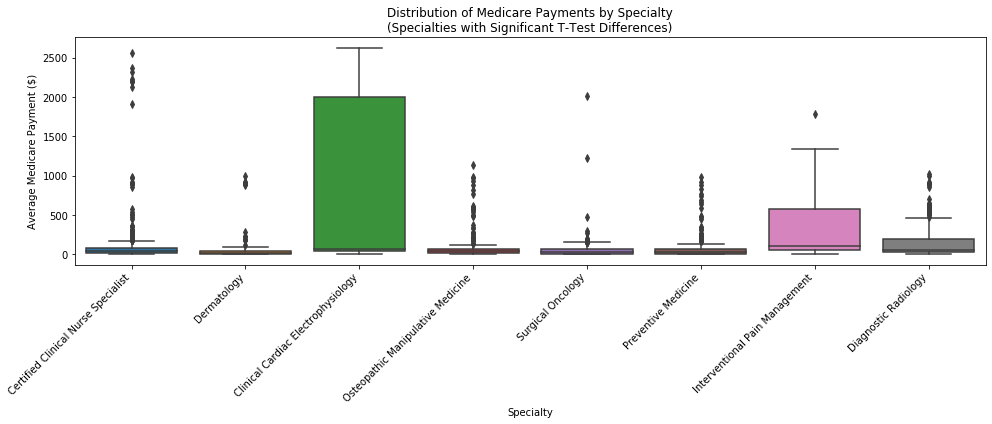

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x='specialty',
    y='avg_suplr_mdcr_pymt_amt_mean'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Medicare Payment ($)')
plt.xlabel('Specialty')
plt.title('Distribution of Medicare Payments by Specialty\n(Specialties with Significant T-Test Differences)')
plt.tight_layout()
plt.show()

In [32]:
import numpy as np

# We already have csv_file and chunksize defined earlier
plot_data = []

for chunk in pd.read_csv(csv_file, chunksize=chunksize):
    tmp = chunk[['specialty', 'avg_suplr_mdcr_pymt_amt_mean']].dropna()
    tmp['log_payment'] = np.log1p(tmp['avg_suplr_mdcr_pymt_amt_mean'])
    plot_data.append(tmp)

plot_df = pd.concat(plot_data, ignore_index=True)

print("Plot data shape:", plot_df.shape)
plot_df.head()

/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3058: DtypeWarning: Columns (161) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


Plot data shape: (873538, 3)


,specialty,avg_suplr_mdcr_pymt_amt_mean,log_payment
0,Hospitalist,31.813932,3.490853
1,Hospitalist,41.764741,3.755714
2,Hospitalist,32.699442,3.517481
3,General Surgery,64.407692,4.180640
4,Family Practice,18.243952,2.957197


In [33]:
plot_df_top = plot_df[plot_df['specialty'].isin(top_specialties)]

print("Specialties being plotted:")
plot_df_top['specialty'].unique()

Specialties being plotted:


array(['Certified Clinical Nurse Specialist', 'Dermatology',
       'Clinical Cardiac Electrophysiology',
       'Osteopathic Manipulative Medicine', 'Surgical Oncology',
       'Preventive Medicine', 'Interventional Pain Management',
       'Diagnostic Radiology'], dtype=object)

## Distribution of Log-Transformed Medicare Payments

Violin plots are used to visualize the full distribution of log-transformed Medicare payments across selected specialties. These plots combine density estimation with embedded summary statistics, allowing for assessment of skewness, concentration, and variability within each specialty.

This visualization provides insight into how payments are distributed among providers, highlighting whether high payment levels are broadly shared or concentrated among a smaller subset of providers.


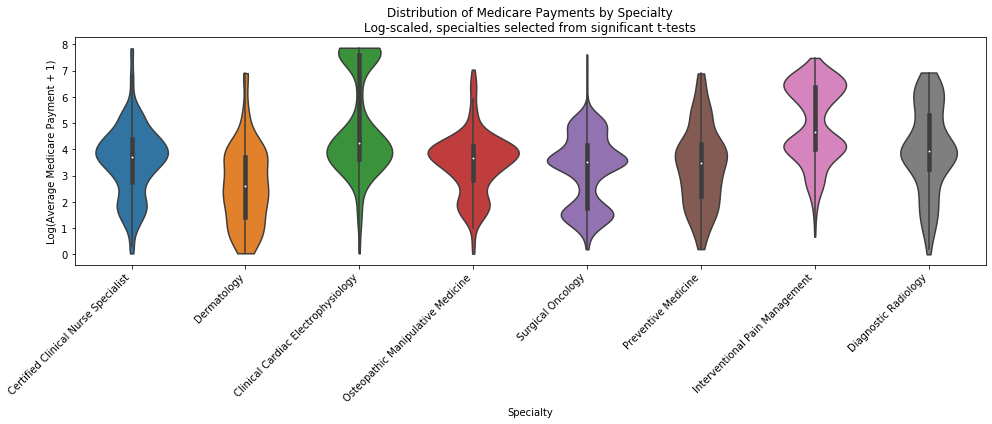

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.violinplot(
    data=plot_df_top,
    x='specialty',
    y='log_payment',
    inner='box',
    cut=0
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Log(Average Medicare Payment + 1)")
plt.xlabel("Specialty")
plt.title(
    "Distribution of Medicare Payments by Specialty\n"
    "Log-scaled, specialties selected from significant t-tests"
)
plt.tight_layout()
plt.show()

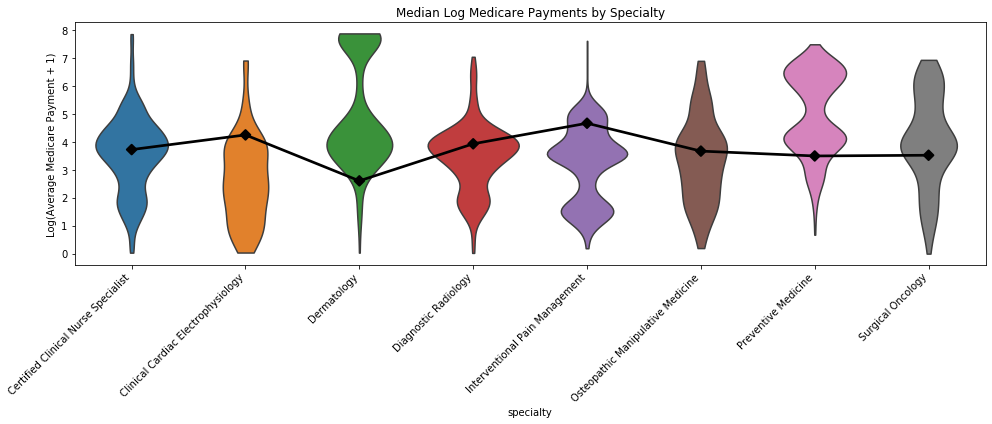

In [35]:
medians = (
    plot_df_top
    .groupby('specialty')['log_payment']
    .median()
    .reset_index()
)

plt.figure(figsize=(14,6))
sns.violinplot(
    data=plot_df_top,
    x='specialty',
    y='log_payment',
    inner=None,
    cut=0
)

sns.pointplot(
    data=medians,
    x='specialty',
    y='log_payment',
    color='black',
    markers='D'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Log(Average Medicare Payment + 1)")
plt.title("Median Log Medicare Payments by Specialty")
plt.tight_layout()
plt.show()


## Box Plot Summary of Medicare Payment Distributions

To complement the violin plots, box plots are included to summarize the median, interquartile range, and overall spread of log-transformed Medicare payments. Outliers are suppressed to prevent extreme values from obscuring central patterns.

While violin plots emphasize distributional shape, the box plots highlight differences in median payment levels and dispersion, making cross-specialty comparisons more interpretable.

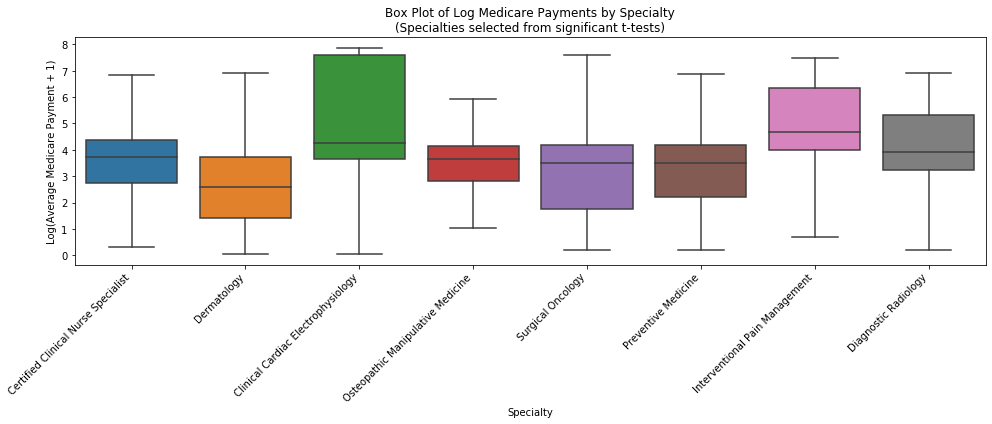

In [36]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=plot_df_top,
    x='specialty',
    y='log_payment',
    showfliers=False  # hides extreme outliers for clarity
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Log(Average Medicare Payment + 1)")
plt.xlabel("Specialty")
plt.title(
    "Box Plot of Log Medicare Payments by Specialty\n"
    "(Specialties selected from significant t-tests)"
)

plt.tight_layout()
plt.show()

## Interpretation in the Context of Fraud Detection

Higher log-transformed Medicare payment values correspond to exponentially larger average reimbursement amounts. For example, a log value above 5 reflects average payments exceeding approximately $150 per claim, while differences of one log unit represent roughly a 2.7-fold increase in payment magnitude.

Specialties with higher median payment levels operate in high-reimbursement environments where relatively small deviations in billing behavior can result in substantial financial impact. Wide interquartile ranges suggest heterogeneity in provider billing practices, which may reflect legitimate differences in case complexity or inconsistent billing behavior.

Long upper tails indicate that a small subset of providers accounts for disproportionately large reimbursements. While not evidence of fraud, such concentration highlights specialties where anomalous billing would have higher financial impact, motivating risk-based auditing rather than provider-level classification.